# GMADL这个函数有什么问题，画图，想一下改进方法

Done: No
Due Date: 2025年10月12日

# 任务：

1. 想一下GMADL这个函数有什么问题，比如，true return = -0.1（或者+0.1）, estimated return = -1，-0.5，-0.1，-0.01, +0.01，+0.1，+0.5，+1的时候，GMADL有什么变化。这样的变化是不是都是合理的？
2. 可以再画个图比较一下。
3. 然后思考一下如果有什么问题，可以怎么改进？

---

## 任务一：GMADL函数测试矩阵

### 测试配置

**参数设定：** a = 100, b = 2（与论文一致）

**测试场景：**

- True return: **+0.1** 和 **-0.1**
- Estimated return: -1, -0.5, -0.1, -0.01, +0.01, +0.1, +0.5, +1

### 计算公式回顾

$$L_i = -left[sigma(a cdot y cdot hat{y}) - 0.5right] times |y|^b$$

其中：

- $y$：观测值（true return）
- $hat{y}$：预测值（estimated return）
- $sigma(x) = frac{1}{1 + e^{-x}}$：sigmoid函数
- $a = 100$：控制sigmoid陡度
- $b = 2$：控制观测值权重

### 关键观察维度

### 1. 方向判断有效性

- [ ]  sigmoid在±0.01附近是否能准确区分方向？
- [ ]  临界点附近（ŷ接近0）是否存在判断模糊区？

### 2. 奖惩幅度对称性

- [ ]  方向正确的奖励与方向错误的惩罚是否对称？
- [ ]  这种对称性对交易策略是否合理？

### 3. 极端预测处理

- [ ]  当ŷ=±1（极端预测）但y=±0.1（中等观测）时，奖惩是否过度？
- [ ]  是否应引入对预测值的约束？

### 4. 梯度连续性

- [ ]  Loss值从负到正的过渡是否平滑？
- [ ]  是否存在梯度消失或爆炸风险？

---

### 预期发现问题

**潜在问题1：小预测值判断失效**

当 |ŷ| < 0.01 时，sigmoid项接近0.5，方向判断信号微弱

**潜在问题2：对称性过强**

奖励幅度 = 惩罚幅度，但交易中"避免亏损 > 追求盈利"

**潜在问题3：缺乏预测置信度调节**

所有预测值同等对待，未考虑模型本身的不确定性

---

## 任务二：可视化方案代码

### 方案1：多子图线图（优先）

**目标：** 深入理解GMADL在不同True Return场景下的连续行为


In [4]:
# 导入必要的库
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 设置绘图参数
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei']  # 支持中文
plt.rcParams['axes.unicode_minus'] = False

# GMADL函数定义
def gmadl(y, y_hat, a=100, b=2):
    """
    计算GMADL损失
    y: 观测值（true return）
    y_hat: 预测值（estimated return）
    a: sigmoid陡度参数
    b: 观测值权重参数
    """
    product = a * y * y_hat
    sigmoid = 1 / (1 + np.exp(-product))
    loss = -(sigmoid - 0.5) * np.abs(y) ** b
    return loss

# MADL函数定义
def madl(y, y_hat):
    """
    计算MADL损失
    """
    if y * y_hat > 0:  # 方向正确
        return -np.abs(y)
    elif y * y_hat < 0:  # 方向错误
        return np.abs(y)
    else:  # 预测为0
        return 0

print("✓ 所有必要的库和函数已导入和定义完成")


✓ 所有必要的库和函数已导入和定义完成


In [5]:
# GMADL测试矩阵 - DataFrame展示结果

# 定义测试参数
true_returns = [-0.1, 0.1]  # 真实收益率
estimated_returns = [-1, -0.5, -0.1, -0.01, 0.01, 0.1, 0.5, 1]  # 预测收益率

# 创建测试结果DataFrame
results = []

for y_true in true_returns:
    for y_hat in estimated_returns:
        # 计算GMADL和MADL损失
        gmadl_loss = gmadl(y_true, y_hat)
        madl_loss = madl(y_true, y_hat)
        
        # 判断方向正确性
        direction_correct = "正确" if y_true * y_hat > 0 else "错误" if y_true * y_hat < 0 else "中性"
        
        # 计算sigmoid值用于分析
        sigmoid_val = 1 / (1 + np.exp(-100 * y_true * y_hat))
        
        results.append({
            '真实收益率': y_true,
            '预测收益率': y_hat,
            '方向判断': direction_correct,
            'GMADL损失': round(gmadl_loss, 4),
            'MADL损失': round(madl_loss, 4),
            '损失差异': round(gmadl_loss - madl_loss, 4),
            'Sigmoid值': round(sigmoid_val, 4),
            '奖励/惩罚': "奖励" if gmadl_loss < 0 else "惩罚"
        })

# 创建DataFrame
df_results = pd.DataFrame(results)

# 设置显示选项
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

print("=" * 80)
print("GMADL函数测试矩阵结果")
print("=" * 80)
print(f"测试参数: a=100, b=2")
print(f"测试场景: {len(true_returns)}个真实收益率 × {len(estimated_returns)}个预测收益率 = {len(results)}个测试点")
print()

# 按真实收益率分组显示
for y_true in true_returns:
    print(f"【真实收益率 = {y_true:+.1f}】")
    subset = df_results[df_results['真实收益率'] == y_true]
    print(subset.to_string(index=False))
    print()

# 统计分析
print("=" * 50)
print("关键观察点分析")
print("=" * 50)

# 1. 方向判断准确性
correct_direction = df_results[df_results['方向判断'] == '正确']
wrong_direction = df_results[df_results['方向判断'] == '错误']

print(f"1. 方向判断统计:")
print(f"   - 方向正确: {len(correct_direction)}个测试点")
print(f"   - 方向错误: {len(wrong_direction)}个测试点")
print(f"   - 平均奖励: {correct_direction['GMADL损失'].mean():.4f}")
print(f"   - 平均惩罚: {wrong_direction['GMADL损失'].mean():.4f}")
print()

# 2. 小预测值分析
small_predictions = df_results[abs(df_results['预测收益率']) <= 0.01]
print(f"2. 小预测值分析 (|ŷ| ≤ 0.01):")
print(f"   - 测试点数: {len(small_predictions)}")
print(f"   - 平均Sigmoid值: {small_predictions['Sigmoid值'].mean():.4f}")
print(f"   - 方向判断信号强度: {abs(small_predictions['Sigmoid值'] - 0.5).mean():.4f}")
print()

# 3. 极端预测分析
extreme_predictions = df_results[abs(df_results['预测收益率']) >= 0.5]
print(f"3. 极端预测分析 (|ŷ| ≥ 0.5):")
print(f"   - 测试点数: {len(extreme_predictions)}")
print(f"   - 平均损失幅度: {abs(extreme_predictions['GMADL损失']).mean():.4f}")
print()

print("✓ 测试矩阵分析完成")


GMADL函数测试矩阵结果
测试参数: a=100, b=2
测试场景: 2个真实收益率 × 8个预测收益率 = 16个测试点

【真实收益率 = -0.1】
 真实收益率  预测收益率 方向判断  GMADL损失  MADL损失    损失差异  Sigmoid值 奖励/惩罚
  -0.1  -1.00   正确  -0.0050    -0.1  0.0950    1.0000    奖励
  -0.1  -0.50   正确  -0.0049    -0.1  0.0951    0.9933    奖励
  -0.1  -0.10   正确  -0.0023    -0.1  0.0977    0.7311    奖励
  -0.1  -0.01   正确  -0.0002    -0.1  0.0998    0.5250    奖励
  -0.1   0.01   错误   0.0002     0.1 -0.0998    0.4750    惩罚
  -0.1   0.10   错误   0.0023     0.1 -0.0977    0.2689    惩罚
  -0.1   0.50   错误   0.0049     0.1 -0.0951    0.0067    惩罚
  -0.1   1.00   错误   0.0050     0.1 -0.0950    0.0000    惩罚

【真实收益率 = +0.1】
 真实收益率  预测收益率 方向判断  GMADL损失  MADL损失    损失差异  Sigmoid值 奖励/惩罚
   0.1  -1.00   错误   0.0050     0.1 -0.0950    0.0000    惩罚
   0.1  -0.50   错误   0.0049     0.1 -0.0951    0.0067    惩罚
   0.1  -0.10   错误   0.0023     0.1 -0.0977    0.2689    惩罚
   0.1  -0.01   错误   0.0002     0.1 -0.0998    0.4750    惩罚
   0.1   0.01   正确  -0.0002    -0.1  0.0998    0.5250    奖励
   0

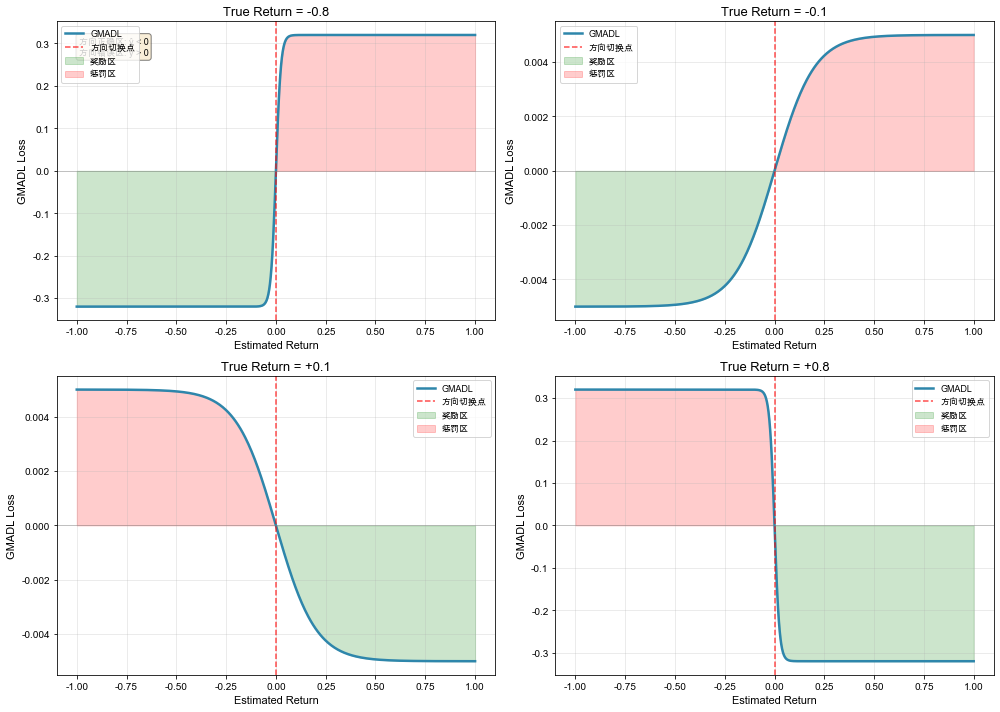

✓ 方案1完成：多子图线图已保存为 gmadl_multiplot.png


In [6]:
# 方案1：多子图线图 - GMADL在不同True Return场景下的连续行为

# 生成预测值范围（连续）
y_hat_range = np.linspace(-1, 1, 500)

# 选择4个代表性的True Return值
true_returns = [-0.8, -0.1, 0.1, 0.8]

# 创建2x2子图
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, y_true in enumerate(true_returns):
    ax = axes[idx]
    
    # 计算该True Return下所有预测值的Loss
    losses = [gmadl(y_true, y_hat) for y_hat in y_hat_range]
    
    # 绘制Loss曲线
    ax.plot(y_hat_range, losses, linewidth=2.5, color='#2E86AB', label='GMADL')
    
    # 标注方向切换点（x=0）
    ax.axvline(x=0, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='方向切换点')
    
    # 标注奖励/惩罚区域
    ax.axhline(y=0, color='gray', linestyle='-', linewidth=0.8, alpha=0.5)
    ax.fill_between(y_hat_range, 0, losses, where=(np.array(losses) < 0), 
                     color='green', alpha=0.2, label='奖励区')
    ax.fill_between(y_hat_range, 0, losses, where=(np.array(losses) > 0), 
                     color='red', alpha=0.2, label='惩罚区')
    
    # 设置标题和标签
    ax.set_title(f'True Return = {y_true:+.1f}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Estimated Return', fontsize=11)
    ax.set_ylabel('GMADL Loss', fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9, loc='best')
    
    # 标注关键点
    if idx == 0:  # 只在第一个子图显示完整图例
        ax.text(0.05, 0.95, f'方向正确区: ŷ < 0\n方向错误区: ŷ > 0', 
                transform=ax.transAxes, fontsize=9, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('gmadl_multiplot.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ 方案1完成：多子图线图已保存为 gmadl_multiplot.png")



---

### 方案A：热力图（全局视角）

**目标：** 一图呈现GMADL在全参数空间的行为模式


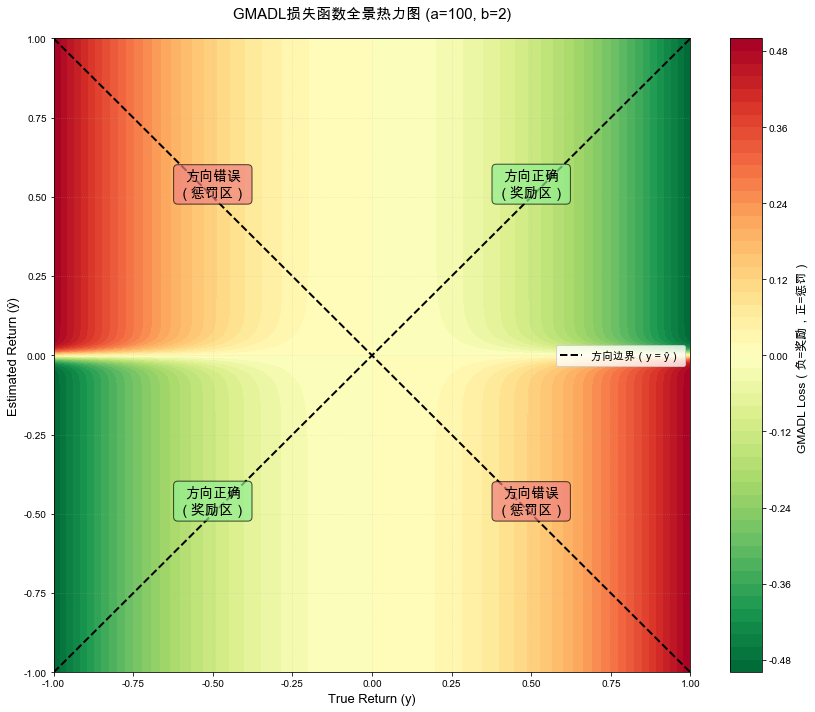

✓ 方案2完成：热力图已保存为 gmadl_heatmap.png


In [7]:
# 方案2：热力图 - GMADL在全参数空间的行为模式

# 生成网格数据
y_range = np.linspace(-1, 1, 200)
y_hat_range = np.linspace(-1, 1, 200)
Y, Y_hat = np.meshgrid(y_range, y_hat_range)

# 计算每个网格点的Loss
Z = np.zeros_like(Y)
for i in range(Y.shape[0]):
    for j in range(Y.shape[1]):
        Z[i, j] = gmadl(Y[i, j], Y_hat[i, j])

# 绘制热力图
fig, ax = plt.subplots(figsize=(12, 10))

# 使用diverging colormap（红绿对比）
im = ax.contourf(Y, Y_hat, Z, levels=50, cmap='RdYlGn_r', vmin=-0.5, vmax=0.5)

# 添加对角线（方向正确的边界）
ax.plot([-1, 1], [-1, 1], 'k--', linewidth=2, label='方向边界（y = ŷ）')
ax.plot([-1, 1], [1, -1], 'k--', linewidth=2)

# 添加颜色条
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('GMADL Loss（负=奖励，正=惩罚）', fontsize=12)

# 标注区域
ax.text(0.5, 0.5, '方向正确\n（奖励区）', fontsize=14, ha='center', 
        bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7))
ax.text(-0.5, 0.5, '方向错误\n（惩罚区）', fontsize=14, ha='center',
        bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.7))
ax.text(0.5, -0.5, '方向错误\n（惩罚区）', fontsize=14, ha='center',
        bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.7))
ax.text(-0.5, -0.5, '方向正确\n（奖励区）', fontsize=14, ha='center',
        bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7))

# 设置标签
ax.set_xlabel('True Return (y)', fontsize=13, fontweight='bold')
ax.set_ylabel('Estimated Return (ŷ)', fontsize=13, fontweight='bold')
ax.set_title('GMADL损失函数全景热力图 (a=100, b=2)', fontsize=15, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3, linestyle=':')
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig('gmadl_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ 方案2完成：热力图已保存为 gmadl_heatmap.png")



---

### 方案C：MADL vs GMADL对比（论文级）

**目标：** 突出两种损失函数的差异，用于论文实验对比


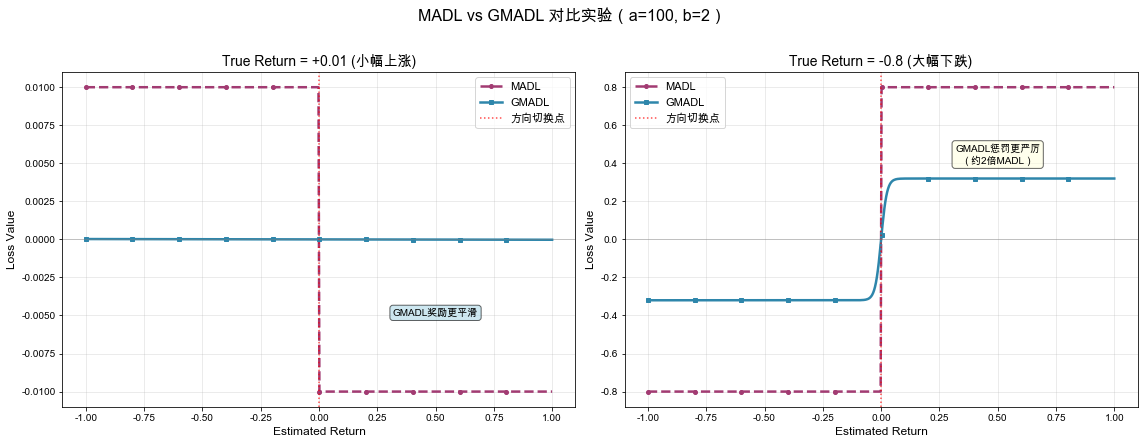

✓ 方案3完成：MADL vs GMADL对比图已保存为 madl_vs_gmadl_comparison.png


In [8]:
# 方案3：MADL vs GMADL对比 - 突出两种损失函数的差异

# 生成预测值范围
y_hat_range = np.linspace(-1, 1, 500)

# 选择2个关键场景（沿用论文示例）
scenarios = [
    {'y': 0.01, 'title': 'True Return = +0.01 (小幅上涨)'},
    {'y': -0.8, 'title': 'True Return = -0.8 (大幅下跌)'}
]

# 创建1x2对比图
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, scenario in enumerate(scenarios):
    ax = axes[idx]
    y_true = scenario['y']
    
    # 计算MADL和GMADL
    madl_losses = [madl(y_true, y_hat) for y_hat in y_hat_range]
    gmadl_losses = [gmadl(y_true, y_hat) for y_hat in y_hat_range]
    
    # 绘制两条曲线
    ax.plot(y_hat_range, madl_losses, linewidth=2.5, color='#A23B72', 
            label='MADL', linestyle='--', marker='o', markevery=50, markersize=4)
    ax.plot(y_hat_range, gmadl_losses, linewidth=2.5, color='#2E86AB', 
            label='GMADL', marker='s', markevery=50, markersize=4)
    
    # 标注方向切换点
    ax.axvline(x=0, color='red', linestyle=':', linewidth=1.5, alpha=0.7, label='方向切换点')
    ax.axhline(y=0, color='gray', linestyle='-', linewidth=0.8, alpha=0.5)
    
    # 设置标题和标签
    ax.set_title(scenario['title'], fontsize=14, fontweight='bold')
    ax.set_xlabel('Estimated Return', fontsize=12)
    ax.set_ylabel('Loss Value', fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=11, loc='best')
    
    # 标注关键差异点
    if idx == 0:  # 小幅上涨场景
        ax.text(0.5, -0.005, 'GMADL奖励更平滑', fontsize=10, ha='center',
                bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.6))
    else:  # 大幅下跌场景
        ax.text(0.5, 0.4, 'GMADL惩罚更严厉\n（约2倍MADL）', fontsize=10, ha='center',
                bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.6))

plt.suptitle('MADL vs GMADL 对比实验（a=100, b=2）', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('madl_vs_gmadl_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ 方案3完成：MADL vs GMADL对比图已保存为 madl_vs_gmadl_comparison.png")
